# Information Theory & Communications - Study Guide
    
This notebook contains a curated summary of key concepts, formulas, and definitions for the Information Theory course (Chapters 1-5). It is designed for quick review and exam preparation.

## Table of Contents
1. [Introduction to Communication Systems](#chapter-1)
2. [Theoretical Basis (Entropy & Information)](#chapter-2)
3. [Coding Theory (Source & Channel)](#chapter-3)
4. [Multiplexing Techniques](#chapter-4)
5. [Signal Modulation](#chapter-5)


## <a id="chapter-1"></a>Chapter 1: Introduction to Communication Systems

### 1.1 General Model
A standard communication system consists of the following blocks:

$$ \text{Source} \xrightarrow{\text{Message}} \text{Transmitter} \xrightarrow{\text{Signal}} \text{Channel} \xrightarrow{\text{Received Sig}} \text{Receiver} \xrightarrow{\text{Est. Message}} \text{Destination} $$

- **Source**: Origin of information (voice, image, text).
- **Transmitter (Tx)**: Converts message to signal suitable for transmission (encoding, modulation).
- **Channel**: The physical medium (wire, fiber, air). Adds **Noise** and **Distortion**.
- **Receiver (Rx)**: Reconstruction of message from signal (demodulation, decoding).
- **Destination**: End user.


## <a id="chapter-2"></a>Chapter 2: Theoretical Basis (Information & Entropy)

### 2.1 Self-Information
The information content of an event $x$ with probability $p(x)$ is: $I(x) = -\log_2 p(x)$.

### 2.2 Entropy (Average Information)
$$ H(X) = -\sum_{i=1}^n p(x_i) \log_2 p(x_i) \quad [\text{bits/symbol}] $$

**Variables:**
- $H(X)$: Average Entropy.
- $p(x_i)$: Probability of symbol $i$.

**When to use:**
- To measure average uncertainty. Determines compression limits.
- **Binary Entropy**: For a system with two outcomes (e.g., Coin Flip) with prob $p$ and $1-p$.


In [1]:
import numpy as np

def calculate_entropy(probabilities):
    '''Calculates Entropy H(X) in bits for a given list of symbol probabilities.'''
    probs = np.array(probabilities)
    # Filter out zero probabilities to avoid log2(0) error
    probs = probs[probs > 0]
    # Check if probs sum to 1 (approx)
    if not np.isclose(np.sum(probs), 1.0):
        print("Warning: Probabilities do not sum to 1. Normalizing...")
        probs = probs / np.sum(probs)
    
    entropy = -np.sum(probs * np.log2(probs))
    return entropy

# Example: Fair coin (p=0.5, 0.5)
print(f"Entropy of Fair Coin: {calculate_entropy([0.5, 0.5]):.4f} bits")
# Example: Biased coin (p=0.9, 0.1)
print(f"Entropy of Biased Coin: {calculate_entropy([0.9, 0.1]):.4f} bits")


Entropy of Fair Coin: 1.0000 bits
Entropy of Biased Coin: 0.4690 bits


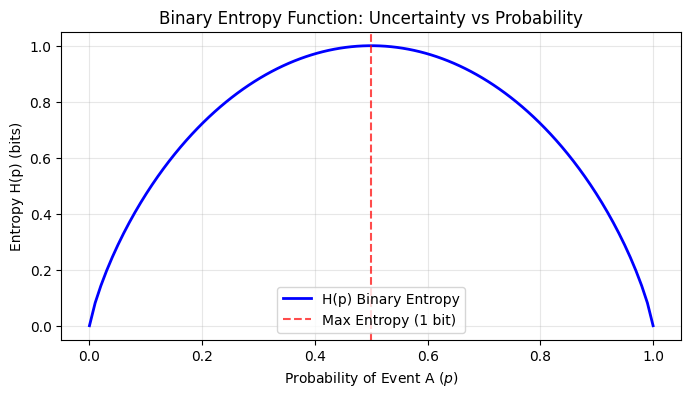

In [2]:
import matplotlib.pyplot as plt

def binary_entropy(p):
    # Avoid log(0) by clipping
    p = np.clip(p, 1e-10, 1 - 1e-10)
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

p_values = np.linspace(0, 1, 100)
H_values = binary_entropy(p_values)

plt.figure(figsize=(8, 4))
plt.plot(p_values, H_values, label='H(p) Binary Entropy', color='blue', linewidth=2)
plt.title('Binary Entropy Function: Uncertainty vs Probability')
plt.xlabel('Probability of Event A ($p$)')
plt.ylabel('Entropy H(p) (bits)')
plt.axvline(0.5, color='red', linestyle='--', alpha=0.7, label='Max Entropy (1 bit)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## <a id="chapter-3"></a>Chapter 3: Coding Theory

### 3.1 Source Coding Theorem (Data Compression)
The limit of lossless compression is determined by the Entropy $H(X)$. average code length $L \ge H(X)$.

#### Huffman Coding
An optimal prefix code algorithm. High probability symbols get shorter codes.

**When to use:**
- Lossless data compression (ZIP, JPEG).


In [3]:
import heapq
from collections import Counter

def huffman_encoding(data):
    '''Builds Huffman Tree and returns codes for characters in data.'''
    # Calculate frequency of each character
    frequency = Counter(data)
    heap = [[weight, [symbol, ""]] for symbol, weight in frequency.items()]
    heapq.heapify(heap)
    
    # Build Tree
    while len(heap) > 1:
        lo = heapq.heappop(heap)
        hi = heapq.heappop(heap)
        for pair in lo[1:]:
            pair[1] = '0' + pair[1]
        for pair in hi[1:]:
            pair[1] = '1' + pair[1]
        heapq.heappush(heap, [lo[0] + hi[0]] + lo[1:] + hi[1:])
        
    return sorted(heapq.heappop(heap)[1:], key=lambda p: (len(p[-1]), p))

data = "BEEP BOOP BEER!"
huff_codes = huffman_encoding(data)
print(f"Huffman Codes for '{data}':")
for char, code in huff_codes:
    print(f"'{char}': {code}")


Huffman Codes for 'BEEP BOOP BEER!':
'B': 00
'E': 10
' ': 010
'O': 110
'P': 111
'!': 0110
'R': 0111


### 3.2 Channel Coding Theorem (Error Correction)
Reliable communication is possible if rate $R < C$. We use **Redundancy** to detect/correct errors.

#### Hamming Distance
The number of positions at which two corresponding symbols differ.
- **Detect $d-1$ errors**: Minimal distance $d$.
- **Correct $(d-1)/2$ errors**.

**Variables:**
- $d_{min}$: Minimum Hamming distance of a code.


In [4]:
def hamming_distance(s1, s2):
    '''Calculates Hamming distance between two strings of equal length.'''
    if len(s1) != len(s2):
        raise ValueError("Strings must be of equal length")
    return sum(c1 != c2 for c1, c2 in zip(s1, s2))

# Example
seq1 = "101010"
seq2 = "111000"
dist = hamming_distance(seq1, seq2)
print(f"Hamming Distance between {seq1} and {seq2}: {dist}")


Hamming Distance between 101010 and 111000: 2


### 3.3 Shannon-Hartley Theorem
$$ C = B \log_2 \left( 1 + \frac{S}{N} \right) \quad [\text{bits/s}] $$

**Variables:**
- $C$: Channel Capacity (bits per second).
- $B$: Channel Bandwidth (Hz).
- $S/N$: Signal-to-Noise Ratio (linear power ratio).

**When to use:**
- To calculate the theoretical maximum speed of a link (e.g., 4G/5G/WiFi).


In [5]:
def shannon_capacity(bandwidth_hz, snr_db):
    '''Calculates Channel Capacity C (bits/s) using Shannon-Hartley theorem.'''
    # Convert SNR from dB to linear scale
    snr_linear = 10 ** (snr_db / 10)
    
    capacity = bandwidth_hz * np.log2(1 + snr_linear)
    return capacity

# Example: Phone line (B=3400 Hz, SNR=35 dB)
B = 3400
SNR_dB = 35
C = shannon_capacity(B, SNR_dB)
print(f"Phone Line Capacity (B={B}Hz, SNR={SNR_dB}dB): {C/1000:.2f} kbps")


Phone Line Capacity (B=3400Hz, SNR=35dB): 39.53 kbps


## <a id="chapter-4"></a>Chapter 4: Multiplexing

### 4.1 Types
1. **FDM**: Frequency Division (Radio).
2. **TDM**: Time Division (GSM).
3. **CDM**: Code Division (GPS).


## <a id="chapter-5"></a>Chapter 5: Modulation

Varying a property of carrier $A \cos(2\pi f_c t + \phi)$.

### 5.1 Digital Modulation & Constellations
We visualize digital modulation using a **Constellation Diagram**, plotting symbols on the complex plane (I vs Q).


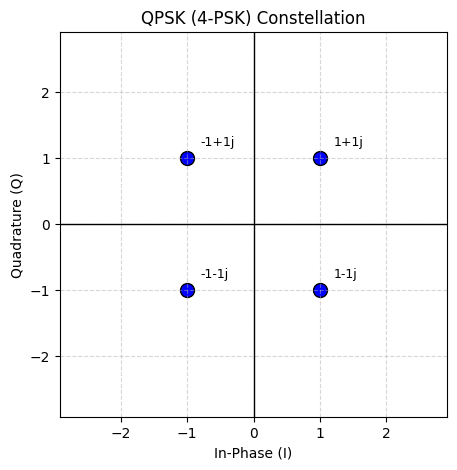

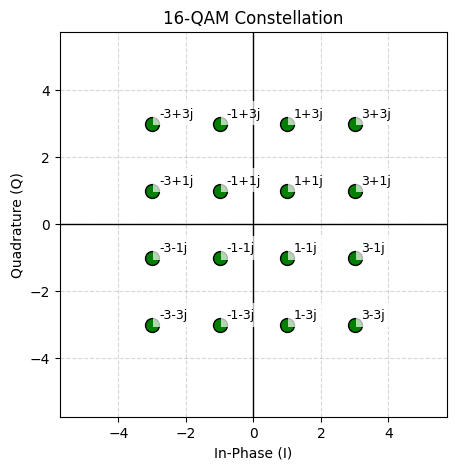

In [6]:
def plot_constellation(points, title, color='blue'):
    plt.figure(figsize=(5, 5))
    plt.scatter(points.real, points.imag, color=color, marker='o', s=100, edgecolors='black')
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    plt.title(title)
    plt.xlabel('In-Phase (I)')
    plt.ylabel('Quadrature (Q)')
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Annotate points
    for p in points:
        label = f"{p.real:.0f}{p.imag:+.0f}j"
        plt.text(p.real + 0.2, p.imag + 0.2, label, fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    
    # Set limits to center nicely
    limit = np.max(np.abs(points)) + 1.5
    plt.xlim(-limit, limit)
    plt.ylim(-limit, limit)
    plt.show()

# 1. QPSK (4-PSK)
# 4 points at phases 45, 135, 225, 315 degrees
qpsk_points = np.array([1+1j, -1+1j, -1-1j, 1-1j])
plot_constellation(qpsk_points, "QPSK (4-PSK) Constellation")

# 2. 16-QAM
# Grid of 4x4 points
x = np.array([-3, -1, 1, 3])
y = np.array([-3, -1, 1, 3])
X, Y = np.meshgrid(x, y)
qam16_points = (X + 1j*Y).flatten()
plot_constellation(qam16_points, "16-QAM Constellation", color='green')
